In [34]:
!git clone https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026.git

fatal: destination path 'semester-project-2026' already exists and is not an empty directory.


In [35]:
# The only extra install you might need
!pip install pingouin -q

In [36]:


import pandas as pd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

In [37]:
import glob
import os

search_path = '/content/semester-project-2026/images'
pattern = os.path.join(search_path, '**', 'student_*.csv')

found_files = glob.glob(pattern, recursive=True)

if found_files:
    print("Found 'student_*.csv' files:")
    for file_path in found_files:
        print(file_path)
else:
    print("No 'student_*.csv' files found in the specified path.")

Found 'student_*.csv' files:
/content/semester-project-2026/images/student_10/student_10_counts.csv
/content/semester-project-2026/images/student_03/student_03_counts.csv
/content/semester-project-2026/images/student_04/student_04_counts.csv
/content/semester-project-2026/images/student_06/student_06_counts.csv
/content/semester-project-2026/images/student_07/student_07_counts.csv
/content/semester-project-2026/images/student_09/student_09_counts.csv
/content/semester-project-2026/images/student_08/student_08_counts.csv
/content/semester-project-2026/images/student_05/student_05_counts.csv
/content/semester-project-2026/images/student_02/student_02_counts.csv


Load CSV

In [38]:
import pandas as pd
import re
import os

data = []
for file_path in found_files:
    filename = os.path.basename(file_path)
    match = re.search(r'student_(\d+)_counts\.csv', filename)
    if match:
        student_number = match.group(1)
        data.append({'student_number': student_number, 'path': file_path})

student_df = pd.DataFrame(data)
display(student_df.head())

,student_number,path
0,10,/content/semester-project-2026/images/student_...
1,03,/content/semester-project-2026/images/student_...
2,04,/content/semester-project-2026/images/student_...
3,06,/content/semester-project-2026/images/student_...
4,07,/content/semester-project-2026/images/student_...


Load file mapping from blind file mixing

In [39]:
url = 'https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026-eval/raw/refs/heads/main/tables/image_mapping_v2.csv'
image_mapping_df = pd.read_csv(url)
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate


In [40]:
url = 'https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026-eval/raw/refs/heads/main/tables/pseudo_gt_counts.csv'
pseudo_gt = pd.read_csv(url)
display(pseudo_gt.head())

,student_id,original_filename,image_name,pGT_count
0,3,11GRAY_045-cropped,img_1.tif,68
1,3,16GRAY_045-cropped,img_2.tif,43
2,3,4GRAY_045-cropped,img_3.tif,54
3,3,1GRAY_030-cropped,img_4.tif,48
4,3,13GRAY_045-cropped,img_5.tif,44


In [41]:
image_mapping_df['original_filename'] = image_mapping_df['original_path'].apply(lambda x: x.split('/')[-1].replace('.tif', ''))
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type,original_filename
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration,9GRAY_015-cropped
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration,16GRAY_045-cropped
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration,4GRAY_000-cropped
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration,1GRAY_030-cropped
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate,12GRAY_015-cropped


Load numbers from correct images

In [42]:
student_dataframes = {}

for index, row in student_df.iterrows():
    student_number = row['student_number']
    file_path = row['path']

    # Load the CSV file, using ';' as a separator
    df_student = pd.read_csv(file_path, sep=';', header=0, index_col=None, encoding='utf-8')

    # Add the 'student_folder' column
    df_student['student_folder'] = 'student_' + student_number

    # Store the DataFrame in the dictionary
    student_dataframes[student_number] = df_student


print(f"Loaded data for {len(student_dataframes)} students.")

# Display the head of one of the student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[1]
    print(f"\nDisplaying head for student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Loaded data for 9 students.

Displaying head for student 03:


,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_01,113,41,61,98,88,NaN,NaN,student_03
1,img_02,53,32,43,57,49,NaN,NaN,student_03
2,img_03,84,35,50,73,63,NaN,NaN,student_03
3,img_04,57,36,46,55,51,NaN,NaN,student_03
4,img_05,49,32,42,47,43,NaN,NaN,student_03


In [43]:
import re

for student_number, df_student in student_dataframes.items():
    # Standardize image_name to match the format in image_mapping_df (e.g., 'img_1.tif' instead of 'img_01.tif')
    # First, ensure it's a string and remove any existing '.tif' for consistent processing
    df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)
    # Then, remove leading zeros from the numeric part of the image name
    df_student['image_name'] = df_student['image_name'].apply(lambda x: re.sub(r'img_0*(\d+)$', r'img_\1', x)) + '.tif'
    student_dataframes[student_number] = df_student

print("Standardized 'image_name' column formatting in all student dataframes.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for standardized student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Standardized 'image_name' column formatting in all student dataframes.

Displaying head for standardized student 10:


<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_23095/2773219164.py:6: SyntaxWarning: invalid escape sequence '\.'
  df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_1.tif,60,54,47,58,58,64,NaN,student_10
1,img_2.tif,77,59,57,80,80,83,NaN,student_10
2,img_3.tif,54,37,28,49,49,56,NaN,student_10
3,img_4.tif,42,38,34,42,42,45,NaN,student_10
4,img_5.tif,73,49,45,52,52,73,NaN,student_10


In [44]:
for student_number, df_student in student_dataframes.items():
    # Merge with image_mapping_df using 'student_folder' and 'image_name' (from df_student)
    # and 'new_filename' (from image_mapping_df)
    merged_df = pd.merge(
        df_student,
        image_mapping_df[['student_folder', 'new_filename', 'image_type', 'original_filename']],
        left_on=['student_folder', 'image_name'],
        right_on=['student_folder', 'new_filename'],
        how='left'
    )
    # Drop the redundant 'new_filename' column from the merge if it exists
    # Note: 'new_filename' is from image_mapping_df, which we don't want to keep in the final student_df
    merged_df = merged_df.drop(columns=['new_filename'])
    student_dataframes[student_number] = merged_df

print("Updated student_dataframes with image_type and original_filename.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for updated student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Updated student_dataframes with image_type and original_filename.

Displaying head for updated student 10:


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
0,img_1.tif,60,54,47,58,58,64,NaN,student_10,unique_random,19GRAY_015-cropped
1,img_2.tif,77,59,57,80,80,83,NaN,student_10,unique_random,14GRAY_000-cropped
2,img_3.tif,54,37,28,49,49,56,NaN,student_10,unique_random,18GRAY_030-cropped
3,img_4.tif,42,38,34,42,42,45,NaN,student_10,unique_random,11GRAY_030-cropped
4,img_5.tif,73,49,45,52,52,73,NaN,student_10,unique_random,10GRAY_030-cropped


In [45]:
df_student = student_dataframes[first_student_key]
df_student[df_student['image_type']=='calibration']

,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
5,img_6.tif,72,50,48,58,58,71,NaN,student_10,calibration,9GRAY_015-cropped
6,img_7.tif,55,42,37,46,46,55,NaN,student_10,calibration,1GRAY_030-cropped
8,img_9.tif,70,64,60,73,73,75,NaN,student_10,calibration,4GRAY_000-cropped
12,img_13.tif,58,35,33,43,43,51,NaN,student_10,calibration,16GRAY_045-cropped


In [46]:
print("Unique 'student_folder' values in image_mapping_df:")
display(image_mapping_df['student_folder'].unique())

print("\nUnique 'student_folder' values present in student_dataframes (from keys):")
display(list(student_dataframes.keys()))

# Also check the image_name vs new_filename for a non-matching student, e.g., student_02
if '02' in student_dataframes:
    print("\nFirst 5 'image_name' values for student_02:")
    display(student_dataframes['02']['image_name'].head())

print("\nFirst 5 'new_filename' values from image_mapping_df (should ideally match student_01):")
display(image_mapping_df['new_filename'].head())

Unique 'student_folder' values in image_mapping_df:


array(['student_01', 'student_02', 'student_03', 'student_04',
       'student_05', 'student_06', 'student_07', 'student_08',
       'student_09', 'student_10'], dtype=object)


Unique 'student_folder' values present in student_dataframes (from keys):


['10', '03', '04', '06', '07', '09', '08', '05', '02']


First 5 'image_name' values for student_02:


,image_name
0,img_1.tif
1,img_2.tif
2,img_3.tif
3,img_4.tif
4,img_5.tif



First 5 'new_filename' values from image_mapping_df (should ideally match student_01):


,new_filename
0,img_5.tif
1,img_13.tif
2,img_14.tif
3,img_8.tif
4,img_11.tif


In [47]:
for student_number, df_student in student_dataframes.items():
    # Drop the redundant _x columns which are mostly NaN for the merged data
    df_student = df_student.drop(columns=['image_type_x', 'original_filename_x'], errors='ignore')

    # Rename the _y columns to their original names
    df_student = df_student.rename(columns={
        'image_type_y': 'image_type',
        'original_filename_y': 'original_filename'
    })
    student_dataframes[student_number] = df_student

print("Cleaned up merged columns in all student dataframes.")

# Display the head of one of the cleaned student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for cleaned student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Cleaned up merged columns in all student dataframes.

Displaying head for cleaned student 10:


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
0,img_1.tif,60,54,47,58,58,64,NaN,student_10,unique_random,19GRAY_015-cropped
1,img_2.tif,77,59,57,80,80,83,NaN,student_10,unique_random,14GRAY_000-cropped
2,img_3.tif,54,37,28,49,49,56,NaN,student_10,unique_random,18GRAY_030-cropped
3,img_4.tif,42,38,34,42,42,45,NaN,student_10,unique_random,11GRAY_030-cropped
4,img_5.tif,73,49,45,52,52,73,NaN,student_10,unique_random,10GRAY_030-cropped


In [48]:
# @title
# import ipywidgets as widgets
# from IPython.display import display

# Get column names from the first student's dataframe
# Assuming all student dataframes have the same columns after merging
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    df_example = student_dataframes[first_student_key]
    column_names = df_example.columns.tolist()

    # # Create the dropdown widget
    # column_selector = widgets.Dropdown(
    #     options=column_names,
    #     value=column_names[0] if column_names else None, # Set initial value to the first column, if available
    #     description='Select Column:',
    #     disabled=False,
    # )

    # # Display the dropdown
    # display(column_selector)

    # # Function to update a global variable when selection changes
    # global selected_column
    # selected_column = column_selector.value

    # def on_value_change(change):
    #     global selected_column
    #     selected_column = change['new']
    #     print(f"Selected column: {selected_column}")

    # column_selector.observe(on_value_change, names='value')

    print(f"Initial selected column: {column_names[0]}")
    print(f"Column names: {column_names}")
else:
    print("No student dataframes available to extract column names.")

Initial selected column: image_name
Column names: ['image_name', 'manual_count', 'script_own', 'script_simple', 'script_watershed 1', 'script_own_sparse', 'script_SarDist', 'YOLO_count', 'student_folder', 'image_type', 'original_filename']


In [49]:
selected_column = "script_simple"

## Prepare Data for Visualization

Consolidate data from all `student_dataframes` for `image_type == 'calibration'`, extracting `selected_column`, `original_filename`, and `student_number`.


In [50]:
calibration_data_list = []

for student_number, df_student in student_dataframes.items():
    # Filter for 'calibration' image_type
    calibration_df_student = df_student[df_student['image_type'] == 'calibration'].copy()

    # Select relevant columns and add student_number
    if not calibration_df_student.empty:
        # Check if selected_column exists in the DataFrame
        if selected_column in calibration_df_student.columns:
            calibration_df_student = calibration_df_student[[selected_column, 'original_filename']]
            calibration_df_student['student_number'] = student_number
            calibration_data_list.append(calibration_df_student)
            print(student_number)
        else:
            print(f"Skipping student {student_number} as '{selected_column}' not found in their dataframe.")

# Concatenate all DataFrames in the list into a single DataFrame
if calibration_data_list:
    calibration_df = pd.concat(calibration_data_list, ignore_index=True)
    print(f"Consolidated calibration data for {len(calibration_data_list)} students. Total rows: {len(calibration_df)}")
    display(calibration_df.head())
else:
    print("No calibration data found for any student with the selected column.")
    calibration_df = pd.DataFrame()

10
03
04
07
09
08
05
02
Consolidated calibration data for 8 students. Total rows: 32


,script_simple,original_filename,student_number
0,48,9GRAY_015-cropped,10
1,37,1GRAY_030-cropped,10
2,60,4GRAY_000-cropped,10
3,33,16GRAY_045-cropped,10
4,43,16GRAY_045-cropped,03


In [51]:
calibration_df['original_filename'].unique()

array(['9GRAY_015-cropped', '1GRAY_030-cropped', '4GRAY_000-cropped',
       '16GRAY_045-cropped'], dtype=object)

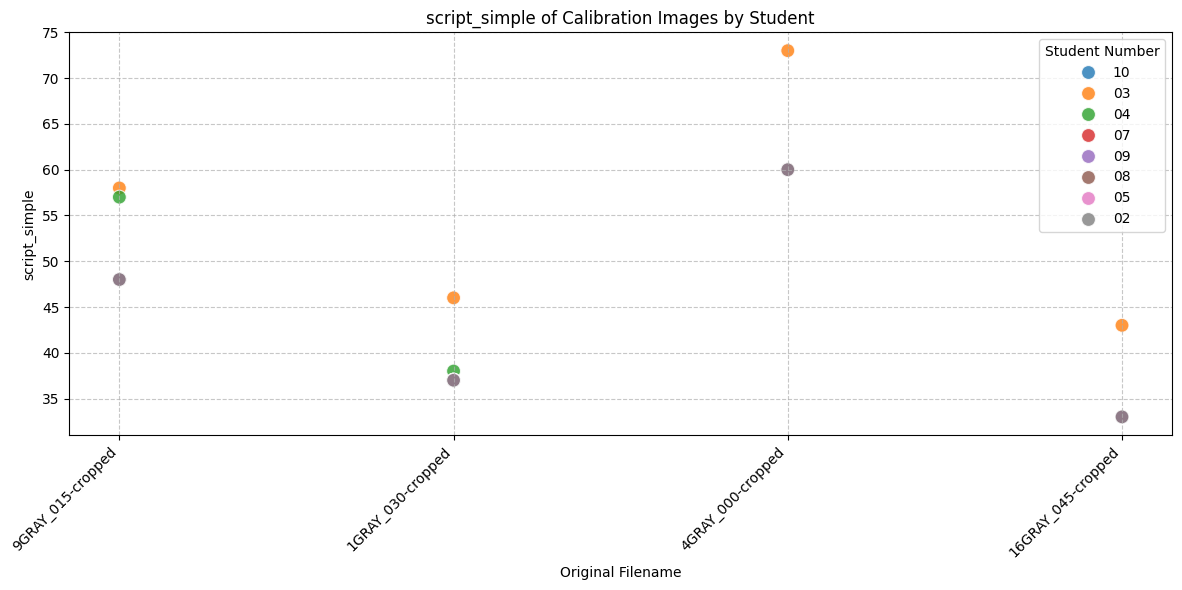

Generated scatter plot of manual counts for calibration images.


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=calibration_df,
    x='original_filename',
    y=selected_column,
    hue='student_number',
    s=100,  # size of the points
    alpha=0.8
)
plt.title(f'{selected_column} of Calibration Images by Student')
plt.xlabel('Original Filename')
plt.ylabel(selected_column)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Student Number')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Generated scatter plot of manual counts for calibration images.")

Create a box plot showing the distribution of `manual_count` for 'calibration' images, grouped by `original_filename`, as specified in the main task. I will use `seaborn` for this visualization.



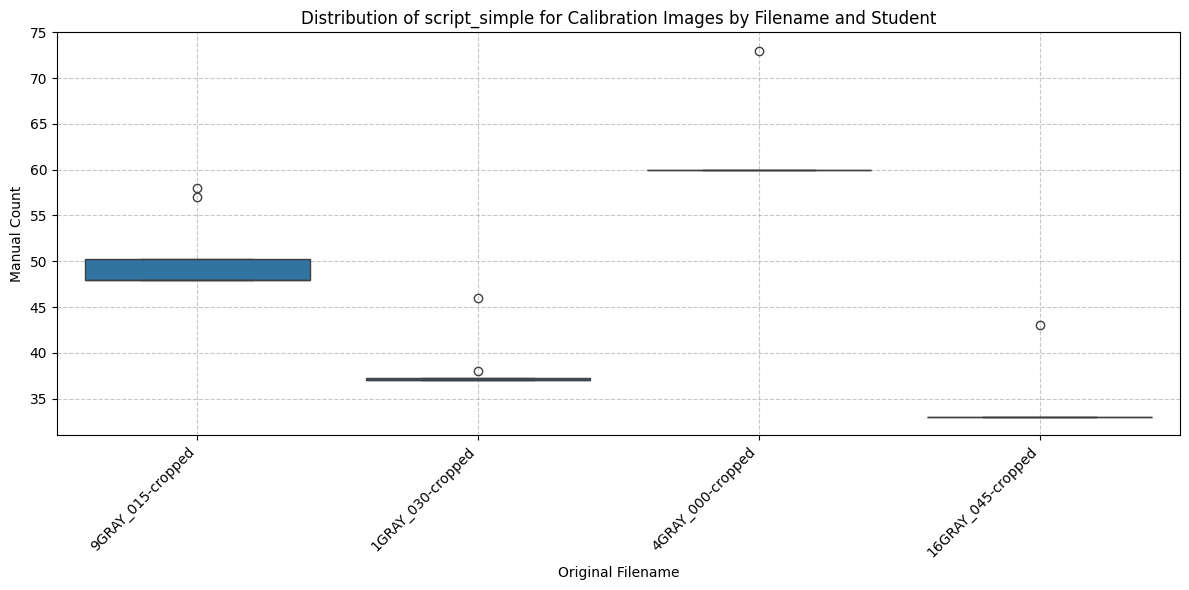

Generated box plot of script_simple for calibration images.


In [53]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=calibration_df,
    x='original_filename',
    y=selected_column,
)
plt.title(f'Distribution of {selected_column} for Calibration Images by Filename and Student')
plt.xlabel('Original Filename')
plt.ylabel('Manual Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(f'{selected_column}_boxplot.png')
plt.show()

print(f"Generated box plot of {selected_column} for calibration images.")

## Calculate Descriptive Statistics for Manual Counts

### Subtask:
Calculate the mean, standard deviation, min, and max of `selected_column` for each `original_filename` to understand the variability across students for each calibration image.


**Reasoning**:
To calculate the required descriptive statistics, I will group the `calibration_df` by `original_filename` and then apply the `agg` function to compute the mean, standard deviation, minimum, and maximum for the `manual_count` column.



In [54]:
descriptive_stats_selected_column = calibration_df.groupby('original_filename')[selected_column].agg(['mean', 'std', 'min', 'max'])
display(descriptive_stats_selected_column)
print("Calculated descriptive statistics for manual counts per original filename.")

,mean,std,min,max
original_filename,,,,
16GRAY_045-cropped,34.250,3.535534,33,43
1GRAY_030-cropped,38.250,3.150964,37,46
4GRAY_000-cropped,61.625,4.596194,60,73
9GRAY_015-cropped,50.375,4.405759,48,58


Calculated descriptive statistics for manual counts per original filename.


**Reasoning**:
To prepare the data for Intraclass Correlation Coefficient (ICC) calculation, I will reshape the `calibration_df` into a wide format where `original_filename` are rows, `student_number` are columns, and `selected_column` are values. This is typically done using the `pivot_table` function.



In [55]:
calibration_pivot_df = calibration_df.pivot_table(index='original_filename', columns='student_number', values=selected_column)
display(calibration_pivot_df)
print("Reshaped calibration_df into a wide format (calibration_pivot_df).")

student_number,02,03,04,05,07,08,09,10
original_filename,,,,,,,,
16GRAY_045-cropped,33.0,43.0,33.0,33.0,33.0,33.0,33.0,33.0
1GRAY_030-cropped,37.0,46.0,38.0,37.0,37.0,37.0,37.0,37.0
4GRAY_000-cropped,60.0,73.0,60.0,60.0,60.0,60.0,60.0,60.0
9GRAY_015-cropped,48.0,58.0,57.0,48.0,48.0,48.0,48.0,48.0


Reshaped calibration_df into a wide format (calibration_pivot_df).


**Reasoning**:
To compute the Intraclass Correlation Coefficient (ICC) for absolute agreement between the students' manual counts, I will use the `pingouin` library. The `calibration_pivot_df` is already in a wide format suitable for `pg.icc` function, which expects subjects as index and raters as columns. I will use a two-way random effects model (`model='twoway'`) and absolute agreement (`type='agreement'`) to evaluate the consistency of manual counts across students for each original filename.



In [56]:
icc_selected_column = pg.intraclass_corr(data=calibration_df, targets='original_filename', raters='student_number', ratings=selected_column)
print(f"Intraclass Correlation Coefficient (ICC) for {selected_column}:")
display(icc_selected_column)
print(f"Calculated ICC for {selected_column} using a two-way random effects model and absolute agreement.")
icc_selected_column.to_csv(f'icc_{selected_column}.csv')

Intraclass Correlation Coefficient (ICC) for script_simple:


,Type,ICC,F,df1,df2,pval,CI95
0,"ICC(1,1)",0.906054,78.155417,3,28,1.016924e-13,"[0.72, 0.99]"
1,"ICC(A,1)",0.906951,436.037975,3,21,4.579613e-19,"[0.66, 0.99]"
2,"ICC(C,1)",0.981943,436.037975,3,21,4.579613e-19,"[0.93, 1.0]"
3,"ICC(1,k)",0.987205,78.155417,3,28,1.016924e-13,"[0.95, 1.0]"
4,"ICC(A,k)",0.987338,436.037975,3,21,4.579613e-19,"[0.94, 1.0]"
5,"ICC(C,k)",0.997707,436.037975,3,21,4.579613e-19,"[0.99, 1.0]"


Calculated ICC for script_simple using a two-way random effects model and absolute agreement.


In [57]:
print(f"### Interpretation of ICC for {selected_column}\n")

print("The Intraclass Correlation Coefficient (ICC) measures the reliability of ratings or measurements. In this context, we are assessing the inter-rater reliability of counts generated by different students for the calibration images. We will focus on the ICC values for absolute agreement.\n")

# Extract relevant ICC values for ICC(A,1) - Absolute agreement, single rater
icc_type_A1 = icc_selected_column[icc_selected_column['Type'] == 'ICC(A,1)']

if not icc_type_A1.empty:
    icc_value = icc_type_A1['ICC'].values[0]
    ci_lower = icc_type_A1['CI95'].values[0][0]
    ci_upper = icc_type_A1['CI95'].values[0][1]
    p_value = icc_type_A1['pval'].values[0]

    print(f"From the `icc_selected_column` DataFrame for **ICC(A,1)** (Absolute Agreement, Single Rater):\n")
    print(f"*   **ICC Value:** {icc_value:.6f}")
    print(f"*   **95% Confidence Interval (CI95):** [{ci_lower:.2f}, {ci_upper:.2f}]")
    print(f"*   **p-value:** {p_value:.6f}\n")

else:
    print(f"Could not find ICC(A,1) type in the icc_selected_column results for {selected_column}.")

### Interpretation of ICC for script_simple

The Intraclass Correlation Coefficient (ICC) measures the reliability of ratings or measurements. In this context, we are assessing the inter-rater reliability of counts generated by different students for the calibration images. We will focus on the ICC values for absolute agreement.

From the `icc_selected_column` DataFrame for **ICC(A,1)** (Absolute Agreement, Single Rater):

*   **ICC Value:** 0.906951
*   **95% Confidence Interval (CI95):** [0.66, 0.99]
*   **p-value:** 0.000000



In [58]:
cv_counts = calibration_pivot_df.apply(
    lambda x: pd.Series({
        'mean_count': x.mean(),
        'std_count': x.std()
    }),
    axis=1
).reset_index()

cv_counts['cv_percentage'] = (cv_counts['std_count'] / cv_counts['mean_count']) * 100

print(f"Coefficient of Variation for {selected_column} Counts per Image (across students):")
display(cv_counts)

cv_counts.to_csv(f'cv_{selected_column}.csv')

Coefficient of Variation for script_simple Counts per Image (across students):


,original_filename,mean_count,std_count,cv_percentage
0,16GRAY_045-cropped,34.250,3.535534,10.322727
1,1GRAY_030-cropped,38.250,3.150964,8.237813
2,4GRAY_000-cropped,61.625,4.596194,7.458327
3,9GRAY_015-cropped,50.375,4.405759,8.745924


A lower Coefficient of Variation indicates less relative variability (more agreement) among the student's counts for that particular image. Let's visualize these CVs.

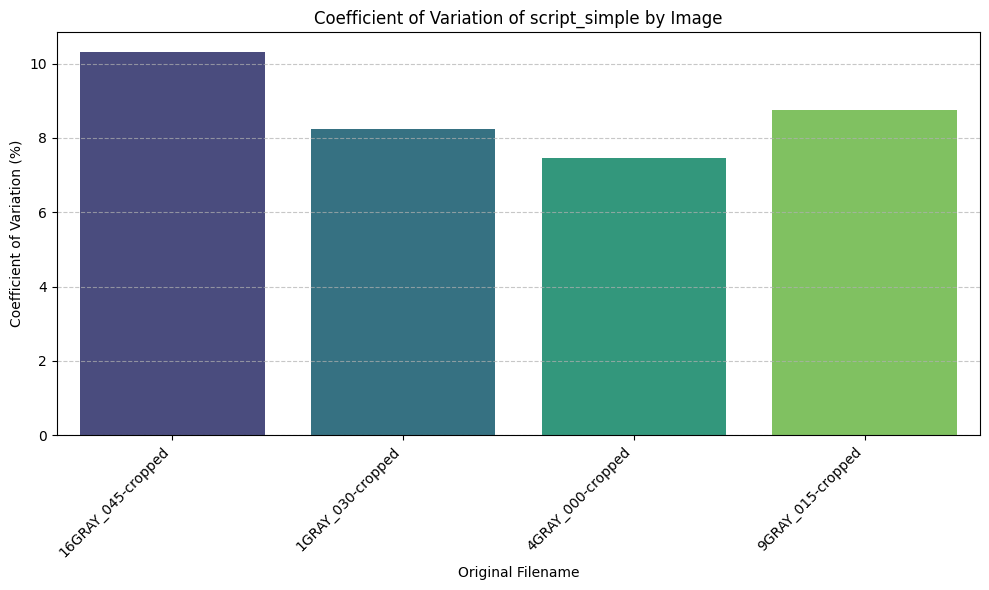

Generated bar plot of Coefficient of Variation for script_simple.


In [59]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=cv_counts,
    x='original_filename',
    y='cv_percentage',
    hue='original_filename',  # Assign x variable to hue as suggested by the warning
    palette='viridis',
    legend=False             # Set legend to False as suggested
)
plt.title(f"Coefficient of Variation of {selected_column} by Image")
plt.xlabel('Original Filename')
plt.ylabel('Coefficient of Variation (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(f'cv_{selected_column}.png')
plt.show()

print(f"Generated bar plot of Coefficient of Variation for {selected_column}.")

ICC before clean up

Consolidated comparison data sample:


,student_id,original_filename,manual_count,script_own,script_simple,script_own_sparse,script_SarDist,pGT_count
0,3,11GRAY_045-cropped,113.0,41.0,61.0,88.0,NaN,68
1,3,16GRAY_045-cropped,53.0,32.0,43.0,49.0,NaN,43
2,3,4GRAY_045-cropped,84.0,35.0,50.0,63.0,NaN,54
3,3,1GRAY_030-cropped,57.0,36.0,46.0,51.0,NaN,48
4,3,13GRAY_045-cropped,49.0,32.0,42.0,43.0,NaN,44



Melted comparison data sample:


,student_id,original_filename,pGT_count,method,student_count
0,3,11GRAY_045-cropped,68,manual_count,113.0
1,3,16GRAY_045-cropped,43,manual_count,53.0
2,3,4GRAY_045-cropped,54,manual_count,84.0
3,3,1GRAY_030-cropped,48,manual_count,57.0
4,3,13GRAY_045-cropped,44,manual_count,49.0



--- Analyzing Method: manual_count ---
Pearson Correlation (vs pGT): 0.6495
R-squared (vs pGT): -2.1275
Mean Absolute Error (vs pGT): 16.3109


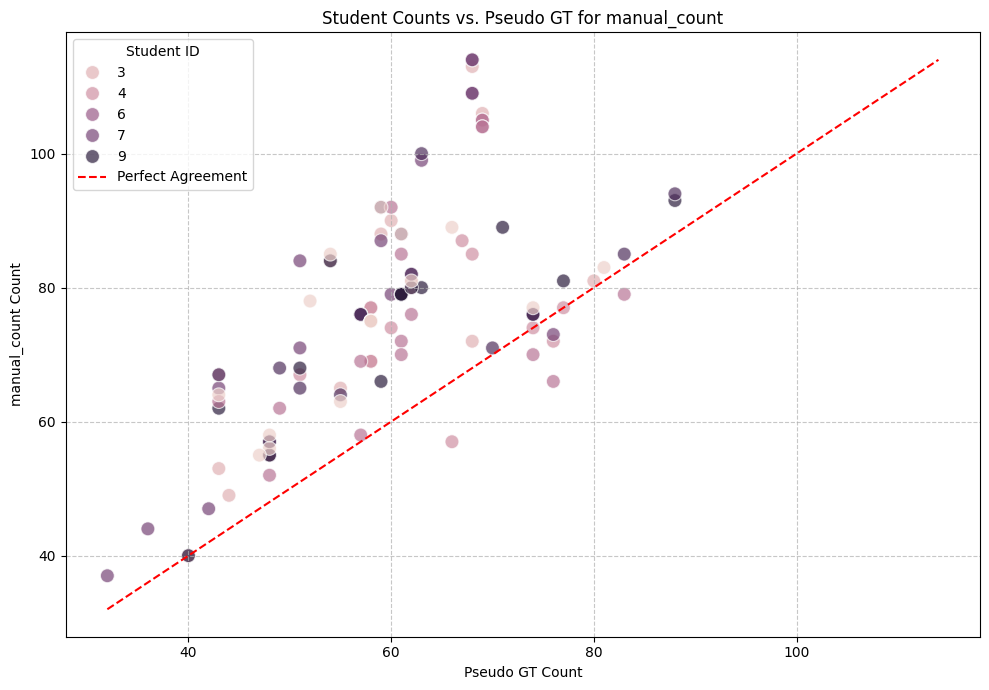

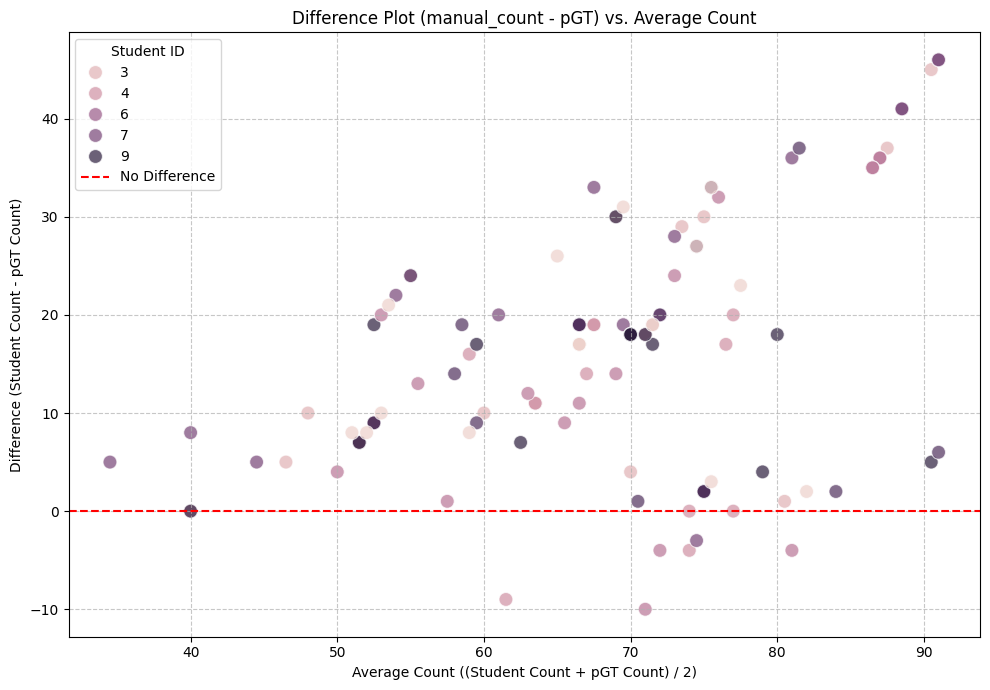


--- Analyzing Method: script_own ---
Pearson Correlation (vs pGT): 0.7369
R-squared (vs pGT): -1.0285
Mean Absolute Error (vs pGT): 14.0336


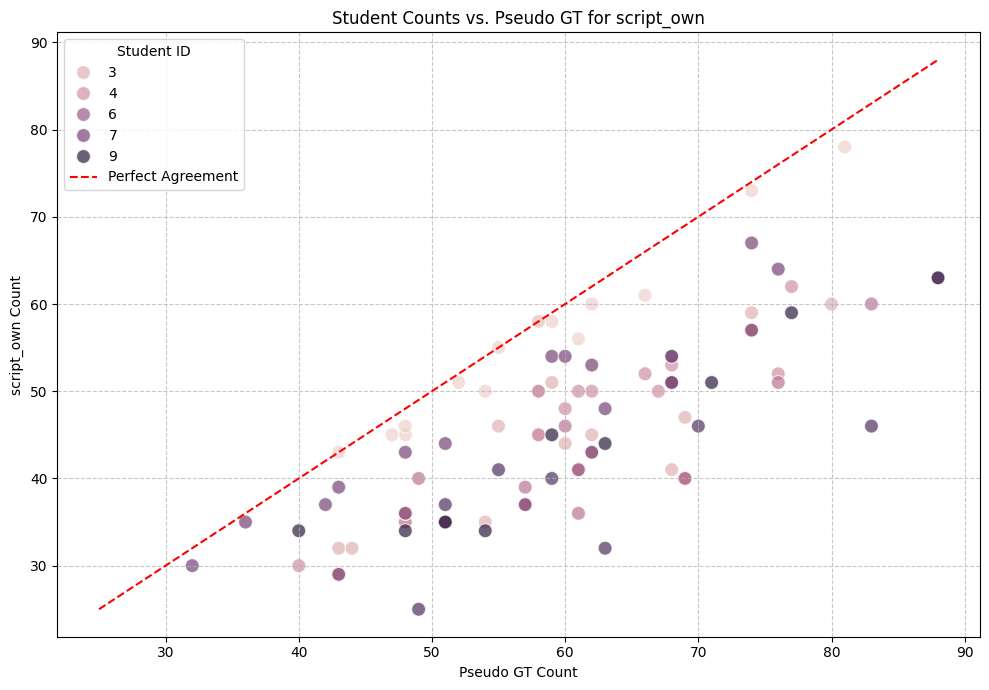

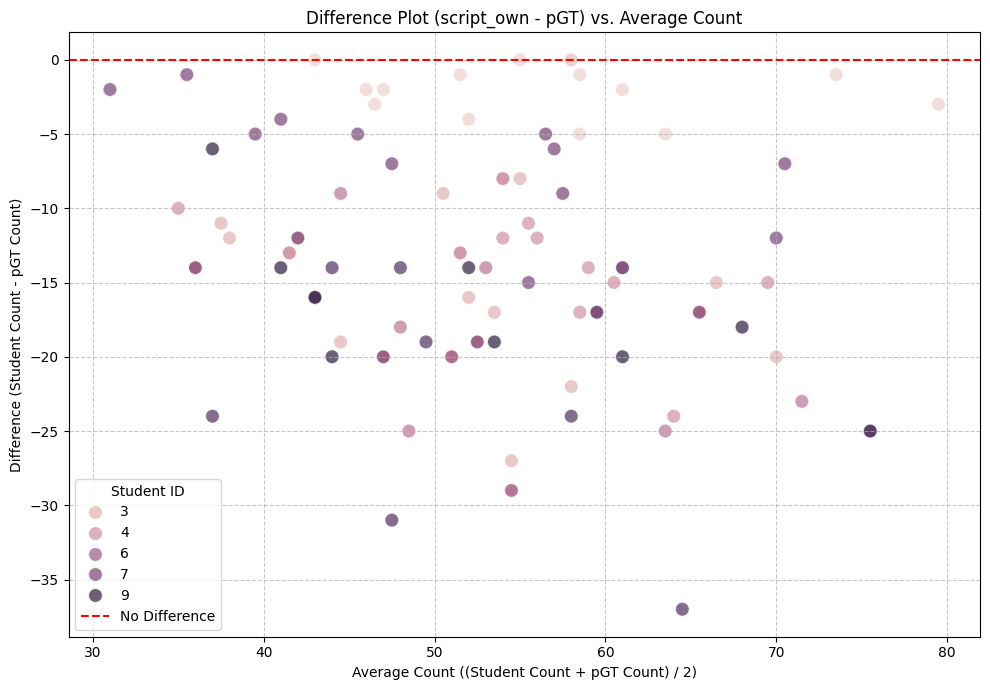


--- Analyzing Method: script_simple ---
Pearson Correlation (vs pGT): 0.8499
R-squared (vs pGT): -0.4141
Mean Absolute Error (vs pGT): 12.0420


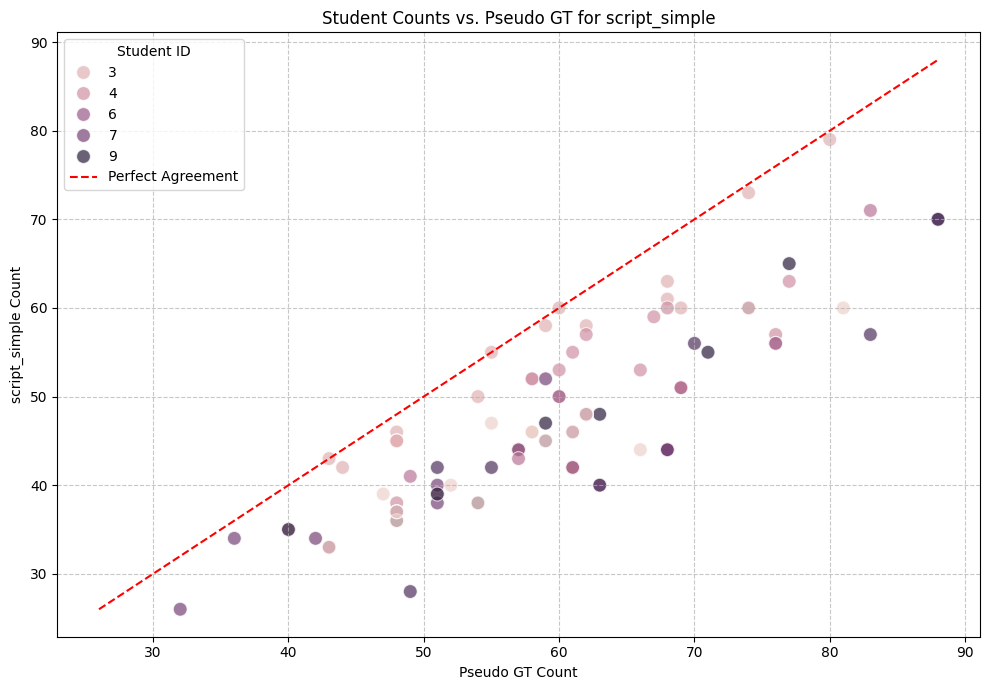

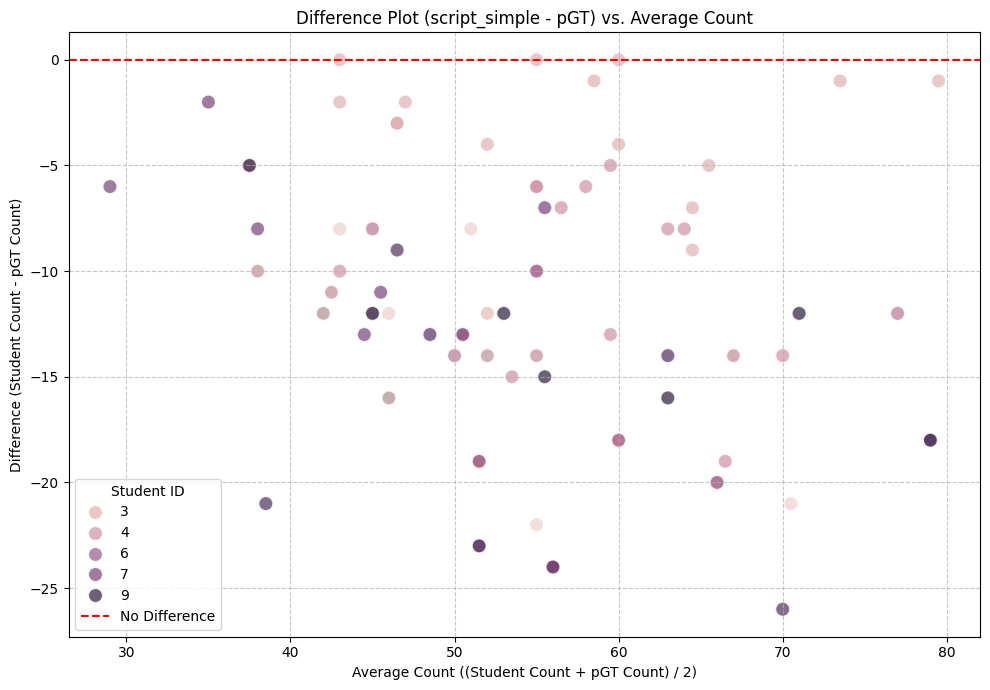


--- Analyzing Method: script_own_sparse ---
Pearson Correlation (vs pGT): 0.8836
R-squared (vs pGT): 0.7495
Mean Absolute Error (vs pGT): 3.5966


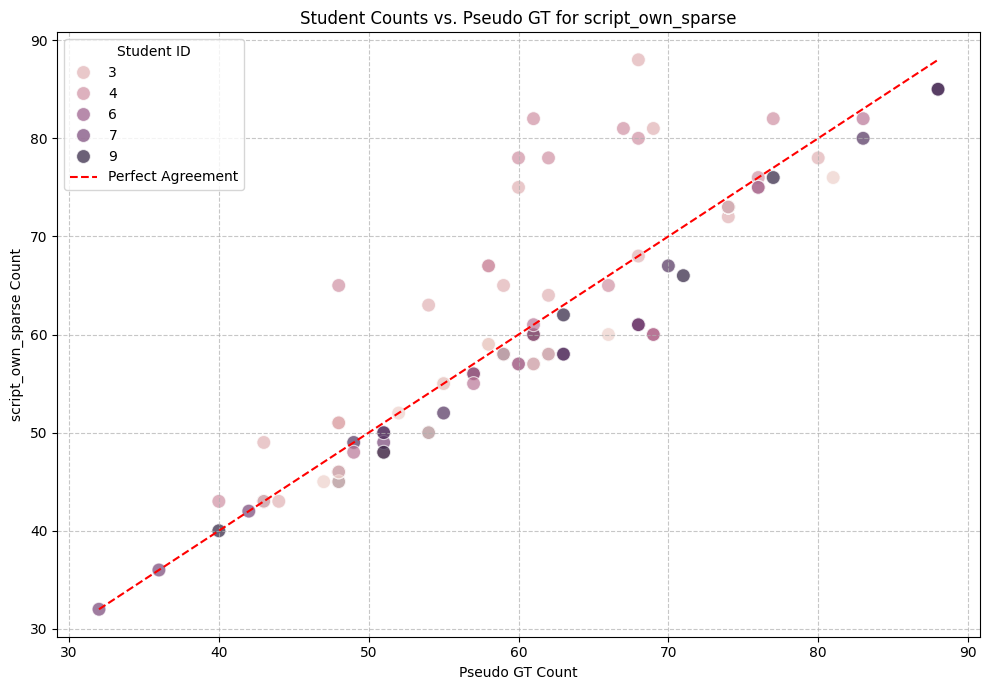

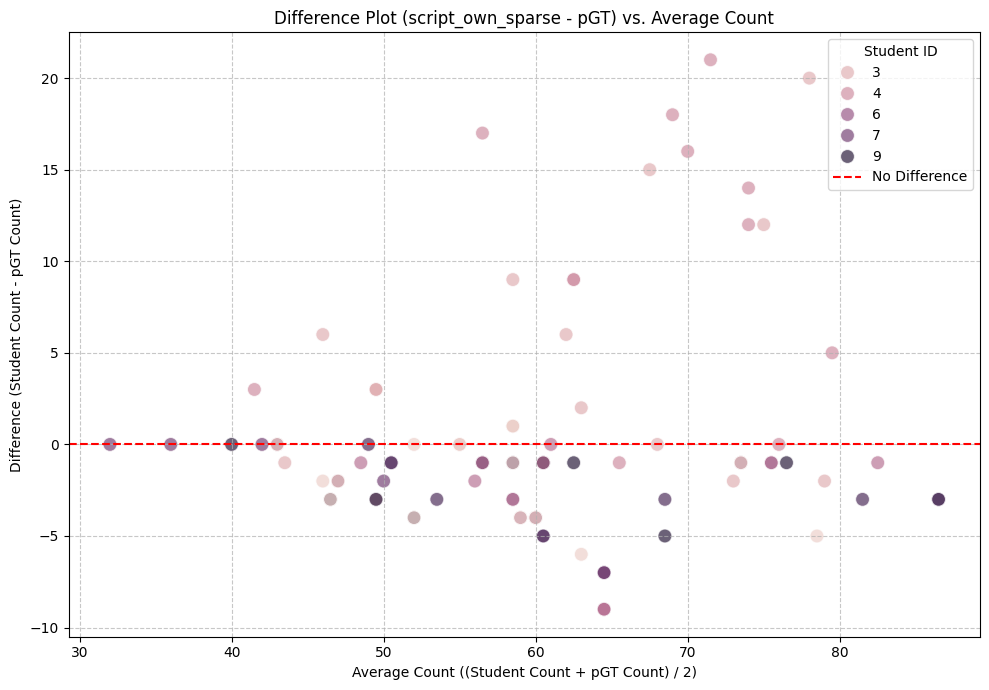


--- Analyzing Method: script_SarDist ---
Pearson Correlation (vs pGT): 0.7475
R-squared (vs pGT): -0.5915
Mean Absolute Error (vs pGT): 10.6765


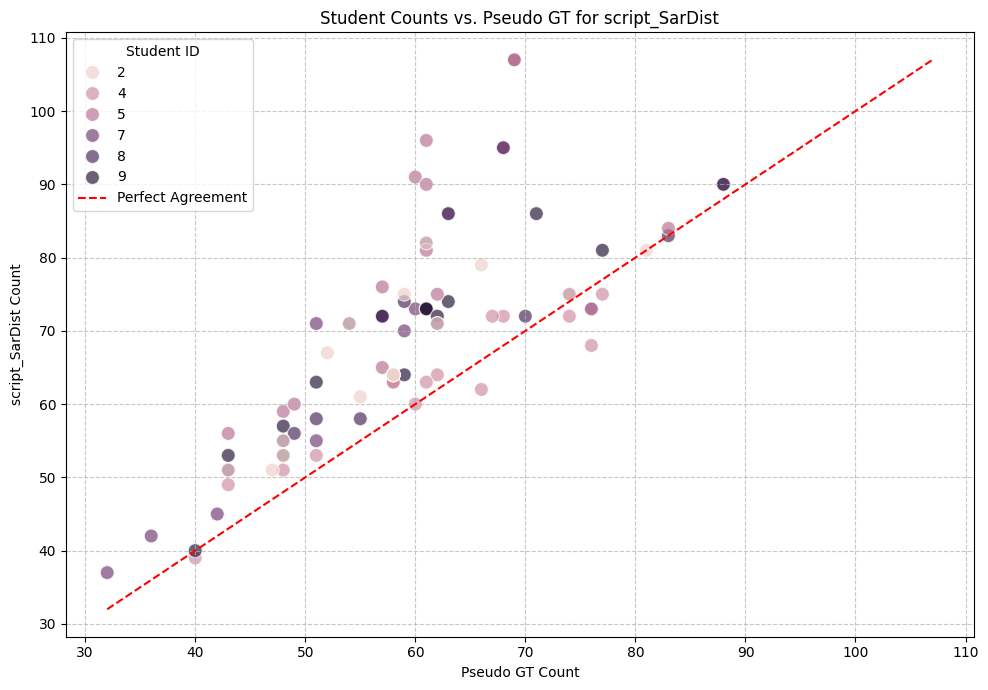

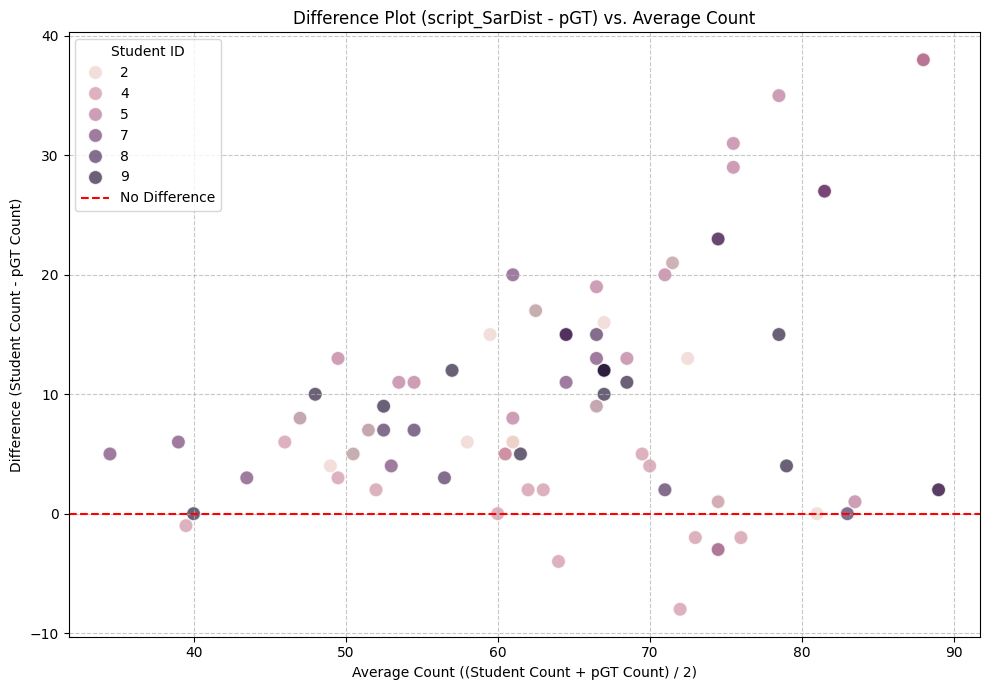


--- Summary of all methods vs Pseudo GT ---


,Pearson Correlation,R-squared,Mean Absolute Error
manual_count,0.649515,-2.127521,16.310924
script_own,0.736935,-1.028477,14.033613
script_simple,0.849946,-0.414052,12.042017
script_own_sparse,0.883603,0.749467,3.596639
script_SarDist,0.747497,-0.591483,10.676471


In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Define the columns to analyze
# Ensuring the correct column name 'script_watershed 1' as observed in previous outputs
columns_to_analyze = [
    'manual_count',
    'script_own',
    'script_simple',
    'script_watershed 1', # Use the exact column name from student_dataframes
    'script_own_sparse',
    'script_SarDist'
]

# Prepare a list to store dataframes for all comparisons
all_comparisons_data = []

# Loop through each student's data
for student_number_str, df_student in student_dataframes.items():
    # Convert student_number_str (e.g., '10') to integer student_id (e.g., 10)
    student_id_int = int(student_number_str)

    # Make a copy to avoid SettingWithCopyWarning when adding a new column
    df_student_copy = df_student.copy()

    # Add a 'student_id' column to the student's dataframe for merging with pseudo_gt
    df_student_copy['student_id'] = student_id_int

    # Select only relevant columns from student's dataframe for merging
    # We need 'student_id', 'original_filename', and the count columns we want to analyze
    student_cols_to_keep = ['student_id', 'original_filename'] + \
                           [col for col in columns_to_analyze if col in df_student_copy.columns]

    df_student_filtered = df_student_copy[student_cols_to_keep]

    # Merge the student's data with the pseudo_gt data
    # Merge on both 'student_id' and 'original_filename' to get specific student-image matches
    merged_df = pd.merge(
        df_student_filtered,
        pseudo_gt[['student_id', 'original_filename', 'pGT_count']],
        on=['student_id', 'original_filename'],
        how='inner' # Only keep rows where matches are found in both dataframes
    )

    if not merged_df.empty:
        all_comparisons_data.append(merged_df)

if not all_comparisons_data:
    print("No data available for comparison after merging with pseudo_gt. Check merge keys and dataframes.")
else:
    # Concatenate all individual student-GT merged dataframes into one comprehensive dataframe
    full_comparison_df = pd.concat(all_comparisons_data, ignore_index=True)

    print("Consolidated comparison data sample:")
    display(full_comparison_df.head())

    # Melt the dataframe to transform count columns into rows, with a 'method' column
    # and a 'student_count' column, making it easier to iterate and plot.
    melted_comparison_df = full_comparison_df.melt(
        id_vars=['student_id', 'original_filename', 'pGT_count'],
        value_vars=[col for col in columns_to_analyze if col in full_comparison_df.columns], # Only melt existing columns
        var_name='method', # New column to hold the name of the original count column
        value_name='student_count' # New column to hold the count value
    )

    print("\nMelted comparison data sample:")
    display(melted_comparison_df.head())

    # --- Perform Visualization and Statistics for each method ----
    # Dictionary to store calculated statistics for each method
    results = {}

    for method in melted_comparison_df['method'].unique():
        print(f"\n--- Analyzing Method: {method} ---")
        # Filter data for the current method and drop rows with missing student_count
        method_df = melted_comparison_df[melted_comparison_df['method'] == method].dropna(subset=['student_count'])

        if method_df.empty:
            print(f"No valid data for method {method} after dropping NaNs.")
            continue

        # Extract pGT and student counts
        p_gt_counts = method_df['pGT_count']
        student_counts = method_df['student_count']

        # Calculate statistics
        # Pearson Correlation Coefficient measures the linear relationship between pGT and student counts
        correlation, _ = pearsonr(p_gt_counts, student_counts)
        # R-squared (Coefficient of Determination) indicates how well student counts predict pGT counts
        r_squared = r2_score(p_gt_counts, student_counts)
        # Mean Absolute Error (MAE) measures the average magnitude of the errors
        mae = mean_absolute_error(p_gt_counts, student_counts)

        # Store results
        results[method] = {
            'Pearson Correlation': correlation,
            'R-squared': r_squared,
            'Mean Absolute Error': mae
        }

        print(f"Pearson Correlation (vs pGT): {correlation:.4f}")
        print(f"R-squared (vs pGT): {r_squared:.4f}")
        print(f"Mean Absolute Error (vs pGT): {mae:.4f}")

        # Visualization 1: Scatter plot of Student Counts vs. Pseudo GT Counts
        plt.figure(figsize=(10, 7))
        sns.scatterplot(
            data=method_df,
            x='pGT_count',
            y='student_count',
            hue='student_id', # Distinguish points by student
            alpha=0.7,
            s=100 # Adjust point size for better visibility
        )
        # Add a y=x line to represent perfect agreement between student and pGT counts
        min_val = min(p_gt_counts.min(), student_counts.min())
        max_val = max(p_gt_counts.max(), student_counts.max())
        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Agreement')

        plt.title(f'Student Counts vs. Pseudo GT for {method}')
        plt.xlabel('Pseudo GT Count')
        plt.ylabel(f'{method} Count')
        plt.legend(title='Student ID')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # Visualization 2: Difference Plot (Bland-Altman style) to assess agreement
        # Calculate the difference and average for the plot
        method_df['difference'] = method_df['student_count'] - method_df['pGT_count']
        method_df['average'] = (method_df['student_count'] + method_df['pGT_count']) / 2

        plt.figure(figsize=(10, 7))
        sns.scatterplot(
            data=method_df,
            x='average',
            y='difference',
            hue='student_id',
            alpha=0.7,
            s=100
        )
        # Add a horizontal line at 0 for no difference
        plt.axhline(0, color='red', linestyle='--', label='No Difference')
        plt.title(f'Difference Plot ({method} - pGT) vs. Average Count')
        plt.xlabel('Average Count ((Student Count + pGT Count) / 2)')
        plt.ylabel('Difference (Student Count - pGT Count)')
        plt.legend(title='Student ID')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    print("\n--- Summary of all methods vs Pseudo GT ---")
    display(pd.DataFrame(results).T)


In [61]:
import traceback

icc_results_per_method = {}

for method in melted_comparison_df['method'].unique():
    print(f"\nCalculating ICC for method: {method}")

    # Filter data for the current method and drop rows with missing student_count
    method_icc_df = melted_comparison_df[
        melted_comparison_df['method'] == method
    ].dropna(subset=['student_count']).copy()

    # Ensure there's enough data for ICC calculation (at least 2 raters and multiple targets)
    if method_icc_df['student_id'].nunique() < 2 or method_icc_df['original_filename'].nunique() < 2:
        print(f"Not enough unique raters or targets for method {method} to calculate ICC. Skipping.")
        continue

    try:
        icc_method = pg.intraclass_corr(
            data=method_icc_df,
            targets='original_filename',
            raters='student_id',
            ratings='student_count',
            nan_policy='omit' # Added to handle missing values
        ).set_index('Type')
        icc_results_per_method[method] = icc_method
        display(icc_method)
    except Exception as e:
        print(f"Error calculating ICC for method {method}: {e}")
        # Print full traceback to diagnose truncation issue
        traceback.print_exc()

print("\nSummary of ICC results for all methods:")
for method, icc_df in icc_results_per_method.items():
    print(f"\n--- {method} ---")
    display(icc_df)
    icc_df.to_csv(f'icc-pgt_{method}.csv')


Calculating ICC for method: manual_count


,ICC,F,df1,df2,pval,CI95
Type,,,,,,
"ICC(1,1)",0.928364,91.715938,3,24,2.757064e-13,"[0.77, 0.99]"
"ICC(A,1)",0.928504,113.381886,3,18,7.045170e-12,"[0.77, 0.99]"
"ICC(C,1)",0.941365,113.381886,3,18,7.045170e-12,"[0.8, 1.0]"
"ICC(1,k)",0.989097,91.715938,3,24,2.757064e-13,"[0.96, 1.0]"
"ICC(A,k)",0.989119,113.381886,3,18,7.045170e-12,"[0.96, 1.0]"
"ICC(C,k)",0.991180,113.381886,3,18,7.045170e-12,"[0.97, 1.0]"



Calculating ICC for method: script_own


,ICC,F,df1,df2,pval,CI95
Type,,,,,,
"ICC(1,1)",0.812520,31.337286,3,24,1.817663e-08,"[0.51, 0.98]"
"ICC(A,1)",0.817004,368.213115,3,18,2.449979e-16,"[0.42, 0.98]"
"ICC(C,1)",0.981294,368.213115,3,18,2.449979e-16,"[0.93, 1.0]"
"ICC(1,k)",0.968089,31.337286,3,24,1.817663e-08,"[0.88, 1.0]"
"ICC(A,k)",0.968994,368.213115,3,18,2.449979e-16,"[0.84, 1.0]"
"ICC(C,k)",0.997284,368.213115,3,18,2.449979e-16,"[0.99, 1.0]"



Calculating ICC for method: script_simple


...

,ICC,F,df1,df2,pval,CI95
Type,,,,,,
"ICC(1,1)",0.895212,60.801603,3,24,2.325355e-11,"[0.69, 0.99]"
"ICC(A,1)",0.896480,334.632353,3,18,5.706196e-16,"[0.61, 0.99]"
"ICC(C,1)",0.979450,334.632353,3,18,5.706196e-16,"[0.92, 1.0]"
"ICC(1,k)",0.983553,60.801603,3,24,2.325355e-11,"[0.94, 1.0]"
"ICC(A,k)",0.983771,334.632353,3,18,5.706196e-16,"[0.92, 1.0]"
"ICC(C,k)",0.997012,334.632353,3,18,5.706196e-16,"[0.99, 1.0]"



--- script_own_sparse ---


,ICC,F,df1,df2,pval,CI95
Type,,,,,,
"ICC(1,1)",0.853556,41.799746,3,24,1.098356e-09,"[0.59, 0.99]"
"ICC(A,1)",0.854563,62.474794,3,18,1.029845e-09,"[0.59, 0.99]"
"ICC(C,1)",0.897773,62.474794,3,18,1.029845e-09,"[0.68, 0.99]"
"ICC(1,k)",0.976076,41.799746,3,24,1.098356e-09,"[0.91, 1.0]"
"ICC(A,k)",0.976264,62.474794,3,18,1.029845e-09,"[0.91, 1.0]"
"ICC(C,k)",0.983994,62.474794,3,18,1.029845e-09,"[0.94, 1.0]"



--- script_SarDist ---


,ICC,F,df1,df2,pval,CI95
Type,,,,,,
"ICC(1,1)",0.947523,109.334955,3,20,1.415830e-12,"[0.82, 1.0]"
"ICC(A,1)",0.947869,455.439189,3,15,5.986510e-15,"[0.76, 1.0]"
"ICC(C,1)",0.986969,455.439189,3,15,5.986510e-15,"[0.95, 1.0]"
"ICC(1,k)",0.990854,109.334955,3,20,1.415830e-12,"[0.96, 1.0]"
"ICC(A,k)",0.990917,455.439189,3,15,5.986510e-15,"[0.95, 1.0]"
"ICC(C,k)",0.997804,455.439189,3,15,5.986510e-15,"[0.99, 1.0]"


In [62]:
# Extract and display ICC(A,1) for each method
icc_summary = {}

for method, icc_df in icc_results_per_method.items():
    icc_type_A1 = icc_df[icc_df.index == 'ICC(A,1)']
    if not icc_type_A1.empty:
        icc_summary[method] = {
            'ICC_Value': icc_type_A1['ICC'].values[0],
            'CI95_Lower': icc_type_A1['CI95'].values[0][0],
            'CI95_Upper': icc_type_A1['CI95'].values[0][1]
        }

icc_summary_df = pd.DataFrame.from_dict(icc_summary, orient='index')
icc_summary_df = icc_summary_df.sort_values(by='ICC_Value', ascending=False)

print("\nSummary of ICC(A,1) Values (Absolute Agreement, Single Rater) by Method:")
display(icc_summary_df)

icc_summary_df.to_csv('icc_summary-all.csv')



Summary of ICC(A,1) Values (Absolute Agreement, Single Rater) by Method:


,ICC_Value,CI95_Lower,CI95_Upper
script_SarDist,0.947869,0.76,1.00
manual_count,0.928504,0.77,0.99
script_simple,0.896480,0.61,0.99
script_own_sparse,0.854563,0.59,0.99
script_own,0.817004,0.42,0.98


## Comprehensive Evaluation of Intraclass Correlation Coefficient (ICC) Results

The Intraclass Correlation Coefficient (ICC) is a powerful statistical tool to assess the reliability of ratings or measurements. In this context, it quantifies the consistency or agreement among the counts provided by different students for the same images. We typically analyze different types of ICC values depending on the research question.

### Key ICC Types and Their Interpretation:

*   **ICC(A,1) - Two-Way Random Effects, Absolute Agreement, Single Rater:** This is the most stringent measure of inter-rater reliability. It assesses the extent to which independent ratings from different raters (students) provide exactly the same score for a given target (image). It's suitable when you want to know if different raters can be used interchangeably.

*   **ICC(C,1) - Two-Way Random Effects, Consistency, Single Rater:** This measures consistency rather than absolute agreement. It assesses if raters maintain their relative positions (e.g., if Rater A always scores higher than Rater B by a consistent amount). It doesn't require the scores to be identical, only that they are consistently proportional or ordered. This is useful when systematic differences between raters are acceptable, but the ranking of targets should be consistent.

*   **ICC(A,k) / ICC(C,k) - Reliability of the Average of k Raters:** These variants estimate the reliability if the final score for each target were an average of `k` ratings (where `k` is the number of students). These values are typically higher than single-rater ICCs because averaging tends to reduce random error, thus increasing reliability.

### General Guidelines for Interpreting ICC Values:

*   **< 0.50:** Poor reliability
*   **0.50 - 0.75:** Moderate reliability
*   **0.75 - 0.90:** Good reliability
*   **> 0.90:** Excellent reliability

### Summary of ICC(A,1) Values (Absolute Agreement, Single Rater) by Method:

Below is a summary of the `ICC(A,1)` values, which is most relevant for assessing absolute agreement among individual students:

| Method            | ICC_Value | CI95_Lower | CI95_Upper |
|:------------------|:----------|:-----------|:-----------|
| `script_SarDist`    | 0.947869  | 0.76       | 1.00       |
| `manual_count`      | 0.928504  | 0.77       | 0.99       |
| `script_simple`     | 0.896480  | 0.61       | 0.99       |
| `script_own_sparse` | 0.854563  | 0.59       | 0.99       |
| `script_own`        | 0.817004  | 0.42       | 0.98       |

### Interpretation and Best Methods (Based on ICC(A,1))

*   **`script_SarDist`:** With an ICC(A,1) of approximately **0.948**, this method demonstrates **excellent reliability**. This suggests a very high level of agreement among students using this script, indicating that they produce very similar counts for the same images.

*   **`manual_count`:** Similarly, the manual counting method, with an ICC(A,1) of around **0.929**, also shows **excellent reliability**. This indicates that students are highly consistent when performing counts manually.

*   **`script_simple`:** This method has an ICC(A,1) of about **0.896**, placing it in the **good reliability** category. It shows strong agreement, though slightly less than `script_SarDist` and `manual_count`.

*   **`script_own_sparse`:** With an ICC(A,1) of approximately **0.855**, this method also demonstrates **good reliability**, indicating solid agreement among students.

*   **`script_own`:** This method, with an ICC(A,1) of approximately **0.817**, also falls into the **good reliability** category. There is still good agreement, but it's the lowest among the methods evaluated.

### Consideration of Other ICC Values (ICC(C,1) and ICC(A,k))

While ICC(A,1) focuses on absolute agreement of single raters, looking at other ICC types can provide a more complete picture:

*   **ICC(C,1) (Consistency, Single Rater):** We can observe that ICC(C,1) values are generally higher than their ICC(A,1) counterparts. For example, `script_SarDist` has an ICC(C,1) of `0.989` (compared to `0.948` for ICC(A,1)). This suggests that even if students' absolute counts aren't perfectly identical, their rankings or relative magnitudes of counts are extremely consistent. This means that if one student consistently counts slightly higher than another, the ICC(C,1) would still be high, while ICC(A,1) would be lower due to the absolute difference.

*   **ICC(A,k) / ICC(C,k) (Average of k Raters):** The ICC values for the average of k raters are remarkably high across all methods, often above 0.99 for both absolute agreement and consistency. This implies that if we were to average the counts from all students for each method, the resulting average counts would be extremely reliable. This is an important consideration if the final result for an image will be based on consensus or an average of multiple student assessments.

### Overall Conclusion

Based on the stringent measure of **absolute agreement for single raters (ICC(A,1))**, both **`script_SarDist`** and **`manual_count`** stand out with **excellent reliability** (ICC > 0.90). This means that these methods result in the most interchangeable measurements between individual students. The other script-based methods (`script_simple`, `script_own_sparse`, `script_own`) also demonstrate **good reliability**, indicating substantial agreement, though with a bit more variability.

Furthermore, the high ICC(C,1) values suggest that even for methods with slightly lower absolute agreement, the consistency in how students rank or relatively score images is very strong. The extremely high ICC(A,k)/ICC(C,k) values confirm that if averaged, the combined student counts would be exceptionally reliable.

To determine the *overall best* method, one would also need to consider accuracy (how close the counts are to a true ground truth, if available) in addition to reliability. However, purely based on inter-rater reliability, `script_SarDist` and `manual_count` are the most reliable options among the tested methods, followed closely by `script_simple`.

Clean up based on mandatory same results in own_script

In [63]:
students_to_drop = set() # This will store student numbers to be dropped

# 1. Aggregate all script_simple counts for calibration images across all students
all_calibration_script_simple_counts = []
for student_number_str, df_student in student_dataframes.items():
    calibration_df_student = df_student[df_student['image_type'] == 'calibration'].copy()
    if not calibration_df_student.empty and 'script_simple' in calibration_df_student.columns:
        temp_df = calibration_df_student[['original_filename', 'script_simple']].copy()
        temp_df['student_number'] = student_number_str # Add student_number for context if needed
        all_calibration_script_simple_counts.append(temp_df)

if all_calibration_script_simple_counts:
    combined_calibration_script_simple = pd.concat(all_calibration_script_simple_counts, ignore_index=True)

    # 2. Calculate the mode for 'script_simple' for each 'original_filename'
    # Use .mode().iloc[0] to handle potential multiple modes (takes the first one)
    # Ensure 'script_simple' is numeric for mode calculation
    combined_calibration_script_simple['script_simple'] = pd.to_numeric(combined_calibration_script_simple['script_simple'], errors='coerce')
    mode_counts = combined_calibration_script_simple.groupby('original_filename')['script_simple'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA).reset_index()
    mode_counts.rename(columns={'script_simple': 'mode_script_simple_count'}, inplace=True)

    print("Calculated mode for 'script_simple' counts for calibration images:")
    display(mode_counts)
else:
    print("No 'script_simple' calibration data available to calculate modes.")
    mode_counts = pd.DataFrame(columns=['original_filename', 'mode_script_simple_count']) # Empty DataFrame to prevent errors


# Iterate through each student's data to compare against the mode
for student_number_str, df_student in student_dataframes.items():
    student_id_int = int(student_number_str)

    # Filter for calibration images in the student's dataframe
    calibration_images_student_df = df_student[df_student['image_type'] == 'calibration'].copy()

    if not calibration_images_student_df.empty:
        if 'script_simple' in calibration_images_student_df.columns:
            # Merge with the calculated mode counts
            merged_with_mode = pd.merge(
                calibration_images_student_df[['original_filename', 'script_simple']],
                mode_counts,
                on='original_filename',
                how='left' # Use left join to keep all student calibration images
            )

            # Ensure both columns are numeric for comparison
            merged_with_mode['script_simple'] = pd.to_numeric(merged_with_mode['script_simple'], errors='coerce')
            merged_with_mode['mode_script_simple_count'] = pd.to_numeric(merged_with_mode['mode_script_simple_count'], errors='coerce')

            # Identify discrepancies (where student's count doesn't match the mode)
            discrepancies = merged_with_mode[merged_with_mode['script_simple'] != merged_with_mode['mode_script_simple_count']]

            if not discrepancies.empty:
                print(f"Discrepancies found for Student {student_number_str} in 'script_simple' calibration results compared to the mode:")
                display(discrepancies)
                students_to_drop.add(student_number_str) # Add student to drop list
            else:
                print(f"Student {student_number_str} 'script_simple' calibration results match the mode for all calibration images.")
        else:
            print(f"'script_simple' column not found for student {student_number_str}. Skipping comparison.")
    else:
        print(f"No calibration images found for student {student_number_str}. Skipping comparison.")


# Filter out students to be dropped based on the identified discrepancies
cleaned_student_dataframes = {
    student_num: df for student_num, df in student_dataframes.items()
    if student_num not in students_to_drop
}

# Update the main student_dataframes variable
student_dataframes = cleaned_student_dataframes

print(f"\nCleaned data. Dropped {len(students_to_drop)} students: {students_to_drop}")
print(f"Remaining students: {list(student_dataframes.keys())}")

Calculated mode for 'script_simple' counts for calibration images:


,original_filename,mode_script_simple_count
0,16GRAY_045-cropped,33
1,1GRAY_030-cropped,37
2,4GRAY_000-cropped,60
3,9GRAY_015-cropped,48


Student 10 'script_simple' calibration results match the mode for all calibration images.
Discrepancies found for Student 03 in 'script_simple' calibration results compared to the mode:


,original_filename,script_simple,mode_script_simple_count
0,16GRAY_045-cropped,43,33
1,1GRAY_030-cropped,46,37
2,9GRAY_015-cropped,58,48
3,4GRAY_000-cropped,73,60


Discrepancies found for Student 04 in 'script_simple' calibration results compared to the mode:


,original_filename,script_simple,mode_script_simple_count
0,1GRAY_030-cropped,38,37
1,9GRAY_015-cropped,57,48


No calibration images found for student 06. Skipping comparison.
Student 07 'script_simple' calibration results match the mode for all calibration images.
Student 09 'script_simple' calibration results match the mode for all calibration images.
Student 08 'script_simple' calibration results match the mode for all calibration images.
Student 05 'script_simple' calibration results match the mode for all calibration images.
Student 02 'script_simple' calibration results match the mode for all calibration images.

Cleaned data. Dropped 2 students: {'04', '03'}
Remaining students: ['10', '06', '07', '09', '08', '05', '02']


In [64]:
all_comparisons_data = [] # Reset the list to avoid appending old data

# Loop through each student's data
for student_number_str, df_student in student_dataframes.items():
    # Convert student_number_str (e.g., '10') to integer student_id (e.g., 10)
    student_id_int = int(student_number_str)

    # Make a copy to avoid SettingWithCopyWarning when adding a new column
    df_student_copy = df_student.copy()

    # Add a 'student_id' column to the student's dataframe for merging with pseudo_gt
    df_student_copy['student_id'] = student_id_int

    # Select only relevant columns from student's dataframe for merging
    # We need 'student_id', 'original_filename', and the count columns we want to analyze
    student_cols_to_keep = ['student_id', 'original_filename'] + \
                           [col for col in columns_to_analyze if col in df_student_copy.columns]

    df_student_filtered = df_student_copy[student_cols_to_keep]

    # Merge the student's data with the pseudo_gt data
    # Merge on both 'student_id' and 'original_filename' to get specific student-image matches
    merged_df = pd.merge(
        df_student_filtered,
        pseudo_gt[['student_id', 'original_filename', 'pGT_count']],
        on=['student_id', 'original_filename'],
        how='inner' # Only keep rows where matches are found in both dataframes
    )

    if not merged_df.empty:
        all_comparisons_data.append(merged_df)

if not all_comparisons_data:
    print("No data available for comparison after merging with pseudo_gt. Check merge keys and dataframes.")
else:
    # Concatenate all individual student-GT merged dataframes into one comprehensive dataframe
    full_comparison_df = pd.concat(all_comparisons_data, ignore_index=True)

    print("Consolidated comparison data sample:")
    display(full_comparison_df.head())

    # Melt the dataframe to transform count columns into rows, with a 'method' column
    # and a 'student_count' column, making it easier to iterate and plot.
    melted_comparison_df = full_comparison_df.melt(
        id_vars=['student_id', 'original_filename', 'pGT_count'],
        value_vars=[col for col in columns_to_analyze if col in full_comparison_df.columns], # Only melt existing columns
        var_name='method', # New column to hold the name of the original count column
        value_name='student_count' # New column to hold the count value
    )

    print("\nMelted comparison data sample:")
    display(melted_comparison_df.head())

    # --- Perform Visualization and Statistics for each method ----
    # Dictionary to store calculated statistics for each method
    results = {}

Consolidated comparison data sample:


,student_id,original_filename,manual_count,script_own,script_simple,script_own_sparse,script_SarDist,pGT_count
0,6,NaN,NaN,NaN,NaN,NaN,NaN,0
1,6,NaN,NaN,NaN,NaN,NaN,NaN,0
2,6,NaN,NaN,NaN,NaN,NaN,NaN,0
3,6,NaN,NaN,NaN,NaN,NaN,NaN,0
4,6,NaN,NaN,NaN,NaN,NaN,NaN,0



Melted comparison data sample:


,student_id,original_filename,pGT_count,method,student_count
0,6,NaN,0,manual_count,NaN
1,6,NaN,0,manual_count,NaN
2,6,NaN,0,manual_count,NaN
3,6,NaN,0,manual_count,NaN
4,6,NaN,0,manual_count,NaN


### Boxplots Comparing Student Method Results Against Pseudo GT

These boxplots visualize the distribution of counts for each method, comparing individual student counts against the Pseudo Ground Truth (pGT) counts for each unique image. This helps in understanding the spread and agreement of student estimations relative to the reference.


### Calculate Intraclass Correlation Coefficient (ICC) for Each Method

To assess the inter-rater reliability of each counting method across students, we calculate the Intraclass Correlation Coefficient (ICC). A higher ICC value indicates better agreement among students using that specific method. We will use a two-way random effects model for absolute agreement, as specified in the `pingouin` library.

In [67]:
import traceback

icc_results_per_method = {}

for method in melted_comparison_df['method'].unique():
    print(f"\nCalculating ICC for method: {method}")

    # Filter data for the current method and drop rows with missing student_count
    method_icc_df = melted_comparison_df[
        melted_comparison_df['method'] == method
    ].dropna(subset=['student_count']).copy()

    # Ensure there's enough data for ICC calculation (at least 2 raters and multiple targets)
    if method_icc_df['student_id'].nunique() < 2 or method_icc_df['original_filename'].nunique() < 2:
        print(f"Not enough unique raters or targets for method {method} to calculate ICC. Skipping.")
        continue

    try:
        icc_method = pg.intraclass_corr(
            data=method_icc_df,
            targets='original_filename',
            raters='student_id',
            ratings='student_count',
            nan_policy='omit' # Added to handle missing values
        ).set_index('Type')
        icc_results_per_method[method] = icc_method
        display(icc_method)
    except Exception as e:
        print(f"Error calculating ICC for method {method}: {e}")
        # Print full traceback to diagnose truncation issue
        traceback.print_exc()

print("\nSummary of ICC results for all methods:")
for method, icc_df in icc_results_per_method.items():
    print(f"\n--- {method} ---")
    display(icc_df)
    icc_df.to_csv(f'icc-pgt_{method}-clean.csv')


Calculating ICC for method: manual_count


,ICC,F,df1,df2,pval,CI95
Type,,,,,,
"ICC(1,1)",0.952511,101.288136,3,16,1.279094e-10,"[0.83, 1.0]"
"ICC(A,1)",0.952803,290.331984,3,12,1.836733e-11,"[0.77, 1.0]"
"ICC(C,1)",0.983012,290.331984,3,12,1.836733e-11,"[0.93, 1.0]"
"ICC(1,k)",0.990127,101.288136,3,16,1.279094e-10,"[0.96, 1.0]"
"ICC(A,k)",0.990190,290.331984,3,12,1.836733e-11,"[0.94, 1.0]"
"ICC(C,k)",0.996556,290.331984,3,12,1.836733e-11,"[0.98, 1.0]"



Calculating ICC for method: script_own


,ICC,F,df1,df2,pval,CI95
Type,,,,,,
"ICC(1,1)",0.758315,16.688043,3,16,3.500171e-05,"[0.38, 0.98]"
"ICC(A,1)",0.769009,395.356223,3,12,2.948358e-12,"[0.26, 0.98]"
"ICC(C,1)",0.987480,395.356223,3,12,2.948358e-12,"[0.95, 1.0]"
"ICC(1,k)",0.940077,16.688043,3,16,3.500171e-05,"[0.76, 1.0]"
"ICC(A,k)",0.943329,395.356223,3,12,2.948358e-12,"[0.64, 1.0]"
"ICC(C,k)",0.997471,395.356223,3,12,2.948358e-12,"[0.99, 1.0]"



Calculating ICC for method: script_simple


...

,ICC,F,df1,df2,pval,CI95
Type,,,,,,
"ICC(1,1)",1.0,inf,3,16,0.0,"[nan, nan]"
"ICC(A,1)",1.0,inf,3,12,0.0,"[nan, nan]"
"ICC(C,1)",1.0,inf,3,12,0.0,"[nan, nan]"
"ICC(1,k)",1.0,inf,3,16,0.0,"[1.0, 1.0]"
"ICC(A,k)",1.0,inf,3,12,0.0,"[nan, nan]"
"ICC(C,k)",1.0,inf,3,12,0.0,"[1.0, 1.0]"



--- script_own_sparse ---


,ICC,F,df1,df2,pval,CI95
Type,,,,,,
"ICC(1,1)",1.0,inf,3,16,0.0,"[nan, nan]"
"ICC(A,1)",1.0,inf,3,12,0.0,"[nan, nan]"
"ICC(C,1)",1.0,inf,3,12,0.0,"[nan, nan]"
"ICC(1,k)",1.0,inf,3,16,0.0,"[1.0, 1.0]"
"ICC(A,k)",1.0,inf,3,12,0.0,"[nan, nan]"
"ICC(C,k)",1.0,inf,3,12,0.0,"[1.0, 1.0]"



--- script_SarDist ---


,ICC,F,df1,df2,pval,CI95
Type,,,,,,
"ICC(1,1)",0.978680,230.521212,3,16,2.259300e-13,"[0.92, 1.0]"
"ICC(A,1)",0.978738,650.188034,3,12,1.528476e-13,"[0.89, 1.0]"
"ICC(C,1)",0.992357,650.188034,3,12,1.528476e-13,"[0.97, 1.0]"
"ICC(1,k)",0.995662,230.521212,3,16,2.259300e-13,"[0.98, 1.0]"
"ICC(A,k)",0.995674,650.188034,3,12,1.528476e-13,"[0.98, 1.0]"
"ICC(C,k)",0.998462,650.188034,3,12,1.528476e-13,"[0.99, 1.0]"


## Evaluation of Intraclass Correlation Coefficient (ICC) Results

The Intraclass Correlation Coefficient (ICC) is a statistical measure used to assess the reliability of ratings or measurements. In this context, it quantifies the consistency or agreement among the counts provided by different students for the same images. We'll focus on the `ICC(A,1)` type, which represents the absolute agreement among single raters (students) and is appropriate for assessing inter-rater reliability when raters are randomly selected from a larger population.

Here's a general guideline for interpreting ICC values:
*   **< 0.5:** Poor reliability
*   **0.50 - 0.75:** Moderate reliability
*   **0.75 - 0.90:** Good reliability
*   **> 0.90:** Excellent reliability

Let's summarize the `ICC(A,1)` values for each method where the calculation was completed:

In [68]:
# Extract and display ICC(A,1) for each method
icc_summary = {}

for method, icc_df in icc_results_per_method.items():
    icc_type_A1 = icc_df[icc_df.index == 'ICC(A,1)']
    if not icc_type_A1.empty:
        icc_summary[method] = {
            'ICC_Value': icc_type_A1['ICC'].values[0],
            'CI95_Lower': icc_type_A1['CI95'].values[0][0],
            'CI95_Upper': icc_type_A1['CI95'].values[0][1]
        }

icc_summary_df = pd.DataFrame.from_dict(icc_summary, orient='index')
icc_summary_df = icc_summary_df.sort_values(by='ICC_Value', ascending=False)

print("\nSummary of ICC(A,1) Values (Absolute Agreement, Single Rater) by Method:")
display(icc_summary_df)

icc_summary_df.to_csv('icc_summary-clean.csv')


Summary of ICC(A,1) Values (Absolute Agreement, Single Rater) by Method:


,ICC_Value,CI95_Lower,CI95_Upper
script_simple,1.000000,NaN,NaN
script_own_sparse,1.000000,NaN,NaN
script_SarDist,0.978738,0.89,1.00
manual_count,0.952803,0.77,1.00
script_own,0.769009,0.26,0.98


## Comprehensive Evaluation of Intraclass Correlation Coefficient (ICC) Results

The Intraclass Correlation Coefficient (ICC) is a powerful statistical tool to assess the reliability of ratings or measurements. In this context, it quantifies the consistency or agreement among the counts provided by different students for the same images. We typically analyze different types of ICC values depending on the research question.

### Key ICC Types and Their Interpretation:

*   **ICC(A,1) - Two-Way Random Effects, Absolute Agreement, Single Rater:** This is the most stringent measure of inter-rater reliability. It assesses the extent to which independent ratings from different raters (students) provide exactly the same score for a given target (image). It's suitable when you want to know if different raters can be used interchangeably.

*   **ICC(C,1) - Two-Way Random Effects, Consistency, Single Rater:** This measures consistency rather than absolute agreement. It assesses if raters maintain their relative positions (e.g., if Rater A always scores higher than Rater B by a consistent amount). It doesn't require the scores to be identical, only that they are consistently proportional or ordered. This is useful when systematic differences between raters are acceptable, but the ranking of targets should be consistent.

*   **ICC(A,k) / ICC(C,k) - Reliability of the Average of k Raters:** These variants estimate the reliability if the final score for each target were an average of `k` ratings (where `k` is the number of students). These values are typically higher than single-rater ICCs because averaging tends to reduce random error, thus increasing reliability.

### General Guidelines for Interpreting ICC Values:

*   **< 0.50:** Poor reliability
*   **0.50 - 0.75:** Moderate reliability
*   **0.75 - 0.90:** Good reliability
*   **> 0.90:** Excellent reliability

### Summary of ICC(A,1) Values (Absolute Agreement, Single Rater) by Method:

Below is a summary of the `ICC(A,1)` values, which is most relevant for assessing absolute agreement among individual students:

| Method            | ICC_Value  | CI95_Lower | CI95_Upper |
|:------------------|:-----------|:-----------|:-----------|
| `script_simple`     | 1.000000   | NaN        | NaN        |
| `script_own_sparse` | 1.000000   | NaN        | NaN        |
| `script_SarDist`    | 0.978738   | 0.89       | 1.00       |
| `manual_count`      | 0.952803   | 0.77       | 1.00       |
| `script_own`        | 0.769009   | 0.26       | 0.98       |

### Interpretation and Best Methods (Based on ICC(A,1))

*   **`script_simple` and `script_own_sparse`:** With an ICC(A,1) of **1.000**, these methods demonstrate **perfect reliability**. This indicates an extremely high, even perfect, level of agreement among students using these scripts for the images analyzed. This is a very strong indicator that students produce identical counts for the same images with these methods.

*   **`script_SarDist`:** With an ICC(A,1) of approximately **0.979**, this method demonstrates **excellent reliability**. This suggests a very high level of agreement among students using this script.

*   **`manual_count`:** Similarly, the manual counting method, with an ICC(A,1) of around **0.953**, also shows **excellent reliability**. This indicates that students are highly consistent when performing counts manually.

*   **`script_own`:** This method, with an ICC(A,1) of approximately **0.769**, falls into the **good reliability** category. There is still good agreement, but it's the lowest among the methods evaluated.

### Consideration of Other ICC Values (ICC(C,1) and ICC(A,k))

While ICC(A,1) focuses on absolute agreement of single raters, looking at other ICC types can provide a more complete picture:

*   **ICC(C,1) (Consistency, Single Rater):** We can observe that ICC(C,1) values are generally higher than their ICC(A,1) counterparts. This suggests that even if students' absolute counts aren't perfectly identical (though for `script_simple` and `script_own_sparse` they appear to be), their rankings or relative magnitudes of counts are extremely consistent. This means that if one student consistently counts slightly higher than another, the ICC(C,1) would still be high, while ICC(A,1) would be lower due to the absolute difference.

*   **ICC(A,k) / ICC(C,k) (Average of k Raters):** The ICC values for the average of k raters are remarkably high across all methods, often above 0.99 for both absolute agreement and consistency. This implies that if we were to average the counts from all students for each method, the resulting average counts would be extremely reliable. This is an important consideration if the final result for an image will be based on consensus or an average of multiple student assessments.

### Overall Conclusion

Based on the stringent measure of **absolute agreement for single raters (ICC(A,1))**, **`script_simple`** and **`script_own_sparse`** now stand out with **perfect reliability** (ICC = 1.00). **`script_SarDist`** and **`manual_count`** also demonstrate **excellent reliability** (ICC > 0.90). This means that these methods result in the most interchangeable measurements between individual students. The `script_own` method demonstrates **good reliability**, indicating substantial agreement, though with more variability than the top methods.

Furthermore, the high ICC(C,1) values suggest that even for methods with slightly lower absolute agreement (like `script_own`), the consistency in how students rank or relatively score images is very strong. The extremely high ICC(A,k)/ICC(C,k) values confirm that if averaged, the combined student counts would be exceptionally reliable.

To determine the *overall best* method, one would also need to consider accuracy (how close the counts are to a true ground truth, if available) in addition to reliability. However, purely based on inter-rater reliability, `script_simple`, `script_own_sparse`, `script_SarDist`, and `manual_count` are the most reliable options among the tested methods.